In [25]:
import Pkg
Pkg.activate("../../../FinancialPlanner")

  Activating project at `c:\Users\matsz\programowanie\Optymalizacja_portfela\FinancialPlanner`


In [26]:
using Revise
using LinearAlgebra
using Distributions
using Random
using StatsPlots
using PDMats
using StatsBase
using Base.Iterators
using DataFrames, TimeSeries, XLSX
using PrettyTables

In [27]:
includet("../VARs/utils.jl")
includet("../VARs/VAR_OLS.jl")

In [175]:
df = DataFrame(XLSX.readtable("../../data/usa_macro_data_s.xlsx", "Quarterly", infer_eltypes=true))
data_source = collapse(TimeArray(df; timestamp = :observation_date), Dates.year, first)

display(returns_summarystats(data_source, 1)) 

,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
A939RX0Q048SBEA,7899.15,67981.0,53310.8,58558.2,39694.0,-0.0631,48243.8,0.8922,-0.8211,6.7489,54030.0
GDPDEF,17.2543,124.163,86.2079,97.3142,61.931,0.415,71.0292,0.8874,-0.6925,4.9963,86.4455
TB3MS,2.0877,5.74,2.4929,4.6075,0.03,0.1519,0.295,0.7423,-1.6044,1.1941,2.215
GS10,1.8301,7.48,4.1218,5.4625,1.32,0.2562,2.6725,0.8403,-1.0307,2.2522,3.97
Price_10Y,1370.84,5318.51,3053.15,4357.17,985.497,-0.0076,1780.06,0.931,-1.3864,2.2272,2946.88
Stock_Price,1210.82,5011.96,1686.05,2037.76,385.92,1.2886,883.707,0.8335,0.7834,1.3925,1313.43
Dividend,18.1645,70.6511,30.0324,42.8758,12.2267,0.891,15.8175,0.8969,-0.5569,1.6534,22.895
E,49.6096,197.883,73.0405,99.4283,12.2067,0.9696,34.9734,0.7798,0.3227,1.4723,61.6783
CAPE,6.4345,42.1856,27.0851,30.4327,14.1222,0.3946,21.8613,0.7436,-0.2481,4.2094,26.8702
USACPIALLQINMEI,19.9645,130.944,87.3209,99.9038,58.0971,0.3379,70.009,0.8855,-0.7344,4.3738,87.709


nothing

In [195]:
freq = 1

cpi = percentchange(data_source[:USACPIALLQINMEI], :log) .* 100
nominal_gdp = percentchange(data_source[:NGDPSAXDCUSQ], :log) .* 100 
gdp = nominal_gdp .- cpi

sr = (data_source[:TB3MS]) .- cpi
term = (data_source[:GS10]) .- (data_source[:TB3MS])
Δd = round.(percentchange(data_source[:Dividend], :log) .* 100, digits=2) .- cpi

returns = percentchange(data_source[:Stock_Price], :log) .* 100
excess_return = returns .- data_source[:TB3MS] ./freq

data= merge(gdp, cpi, sr, term, Δd, excess_return)

start = Date(1985, 01,01)
end_d = Date(2024, 12, 31)
s_data = to(from(data, start),end_d)

display(returns_summarystats(s_data, freq)) 
display(cor(values(s_data)))



,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
NGDPSAXDCUSQ_USACPIALLQINMEI,1.4679,4.9744,2.1415,3.0346,-1.8518,-0.3331,1.4825,0.4158,0.5814,1.4589,2.0384
USACPIALLQINMEI,1.4629,7.6653,2.4626,2.9969,-0.0627,1.3585,1.654,0.2539,3.6385,1.6834,2.3952
TB3MS_USACPIALLQINMEI,2.2487,3.5983,-0.0317,2.0404,-7.3553,-0.7448,-1.5778,0.4673,1.5289,-0.0141,-0.1871
GS10_TB3MS,1.2761,3.61,1.593,2.71,-1.07,-0.2472,0.57,0.545,-0.6884,1.2484,1.63
Dividend_USACPIALLQINMEI,7.173,14.6122,2.8529,7.7785,-24.8231,-1.595,-0.7346,0.4289,4.8762,0.3977,3.146
Stock_Price_TB3MS,17.1257,30.2667,5.3386,16.2558,-52.2433,-1.2928,-0.5694,0.001,2.2673,0.3117,7.3931


nothing

6×6 Matrix{Float64}:
  1.0         0.0368915   0.205054   -0.153589    0.334405    0.52086
  0.0368915   1.0        -0.431166   -0.325312   -0.124618    0.0535172
  0.205054   -0.431166    1.0        -0.288418    0.0248722  -0.0397142
 -0.153589   -0.325312   -0.288418    1.0        -0.263222   -0.0333683
  0.334405   -0.124618    0.0248722  -0.263222    1.0         0.0290786
  0.52086     0.0535172  -0.0397142  -0.0333683   0.0290786   1.0

In [196]:
s_data

33×6 TimeArray{Float64, 2, Date, Matrix{Float64}} 1992-01-01 to 2024-01-01
┌────────────┬──────────────────────────────┬─────────────────┬─────────────────
│            │ NGDPSAXDCUSQ_USACPIALLQINMEI │ USACPIALLQINMEI │ TB3MS_USACPIAL ⋯
├────────────┼──────────────────────────────┼─────────────────┼─────────────────
│ 1992-01-01 │                     0.861539 │        0.699545 │                ⋯
│ 1993-01-01 │                      2.45079 │         3.14709 │             -0 ⋯
│ 1994-01-01 │                      3.09562 │         2.48459 │              0 ⋯
│ 1995-01-01 │                      2.75667 │         2.80069 │                ⋯
│ 1996-01-01 │                      1.79642 │         2.70287 │                ⋯
│ 1997-01-01 │                       3.1876 │         2.90366 │                ⋯
│ 1998-01-01 │                       4.3985 │         1.45169 │                ⋯
│ 1999-01-01 │                      4.31342 │         1.65396 │                ⋯
│     ⋮      │              ⋮     

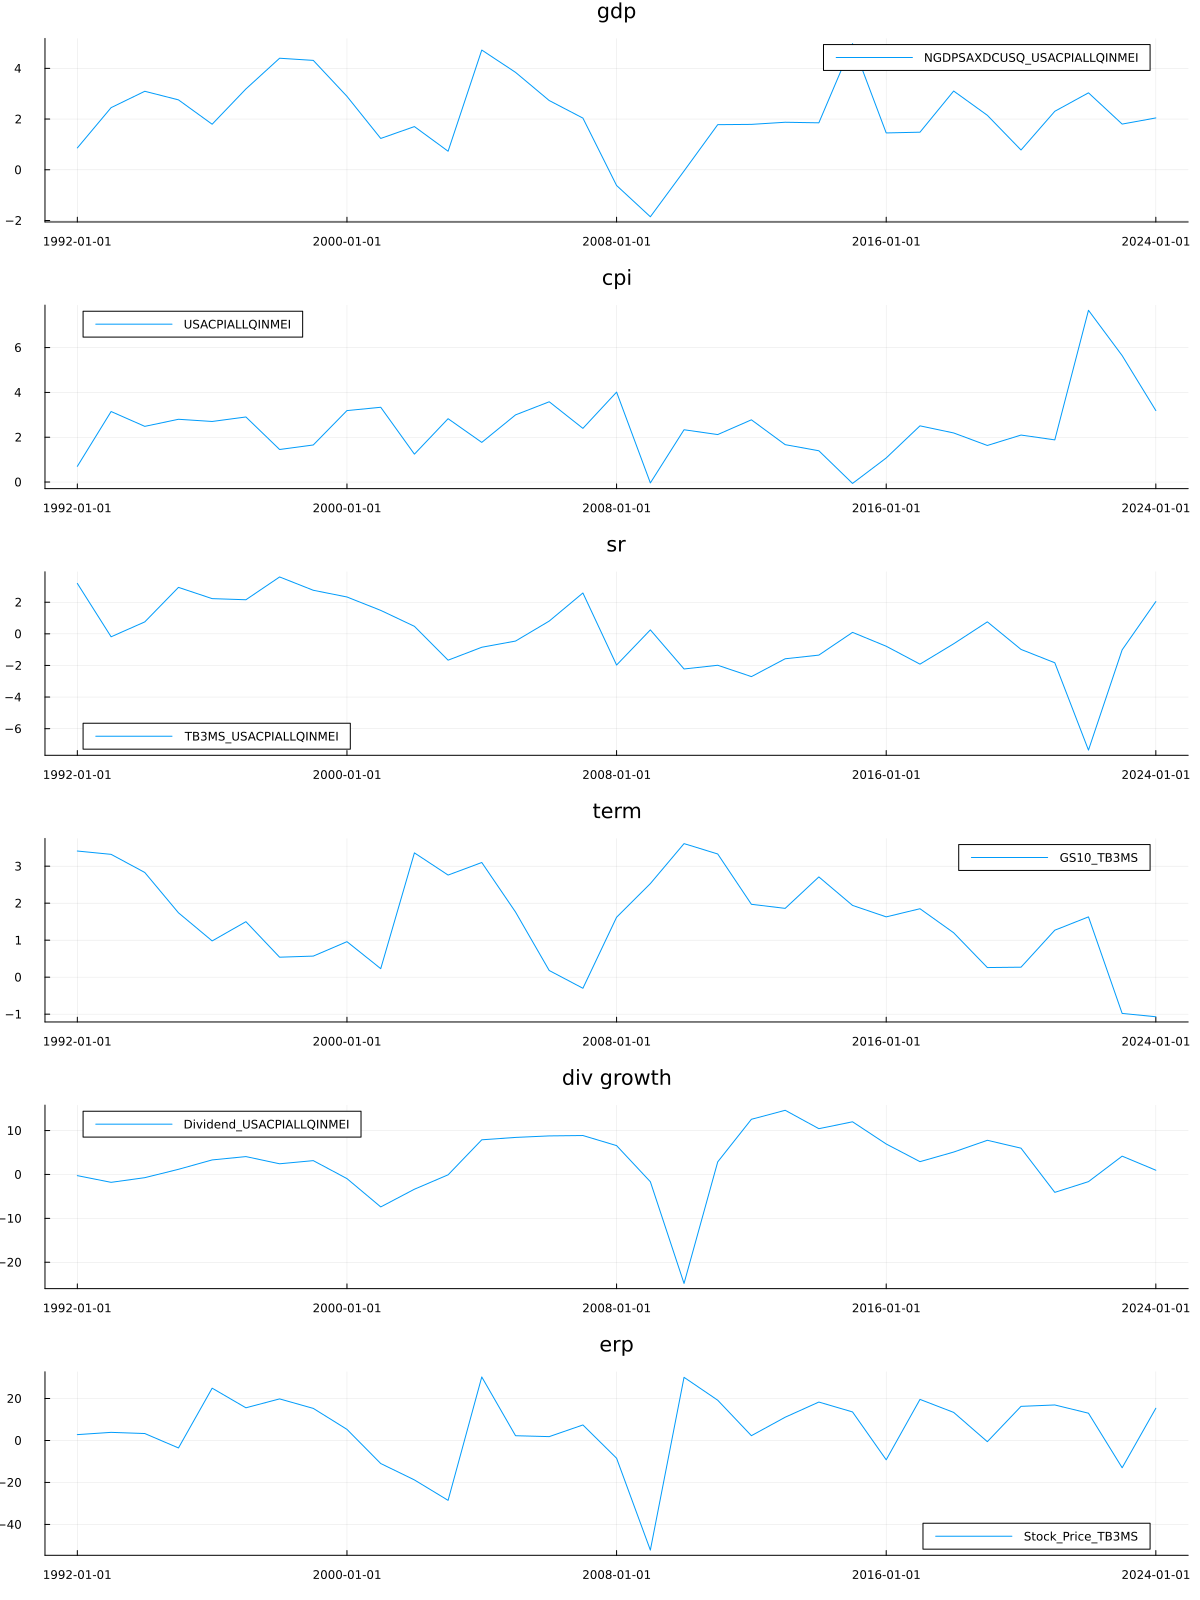

In [197]:
plot(s_data; layout = (6,1), size=(1200,1600), title=["gdp" "cpi" "sr" "term" "div growth" "erp"])

In [198]:
assets_names = colnames(s_data)
T, n_assets = size(s_data)
model = VARModel(s_data)
model_summary(model)

,const,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS,std
NGDPSAXDCUSQ_USACPIALLQINMEI,0.7682,0.3463,0.0398,0.0477,0.3069,-0.0095,0.0181,1.3668
USACPIALLQINMEI,2.4578,0.4132,-0.0138,-0.1868,-0.2956,-0.0916,-0.0096,1.3732
TB3MS_USACPIALLQINMEI,-4.5579,0.198,1.1661,0.8711,0.6115,0.077,-0.0019,1.4625
GS10_TB3MS,2.3587,-0.3895,-0.2831,0.0645,0.4495,-0.0138,-0.0007,0.7044
Dividend_USACPIALLQINMEI,-5.5535,0.632,0.9538,-0.3915,1.5005,0.4748,0.1763,5.3071
Stock_Price_TB3MS,22.4125,-0.7165,-4.3933,-0.8436,-2.6701,-0.2009,0.048,18.1026


,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS
NGDPSAXDCUSQ_USACPIALLQINMEI,1.0,-0.1,0.26,-0.04,0.14,0.68
USACPIALLQINMEI,-0.1,1.0,-0.76,-0.15,-0.24,0.12
TB3MS_USACPIALLQINMEI,0.26,-0.76,1.0,-0.22,-0.04,0.17
GS10_TB3MS,-0.04,-0.15,-0.22,1.0,0.14,-0.32
Dividend_USACPIALLQINMEI,0.14,-0.24,-0.04,0.14,1.0,0.16
Stock_Price_TB3MS,0.68,0.12,0.17,-0.32,0.16,1.0


In [199]:
#unconditional mean
c = model.C[1,:]
Β = model.C[2:end,:]

uμ = inv(I(6) - Β') * c

Dict(zip(colnames(s_data), uμ))



Dict{Symbol, Float64} with 6 entries:
  :USACPIALLQINMEI              => 2.63545
  :Dividend_USACPIALLQINMEI     => 2.77404
  :NGDPSAXDCUSQ_USACPIALLQINMEI => 2.06217
  :Stock_Price_TB3MS            => 5.79365
  :TB3MS_USACPIALLQINMEI        => -0.377772
  :GS10_TB3MS                   => 1.34908

In [200]:
scenarios = simulate(model, 25*freq, 10_000)
#periods = [2,6, 16, 26]
periods = [1,5, 15, 25] 
ret_in_years = cum_returns_in_periods(scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:n_assets
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS
1,2.0446,3.1896,2.0404,-1.07,0.9604,15.3508
5,1.8785,2.9002,0.4283,0.6001,0.6339,8.5649
15,2.0113,2.7225,-0.0408,1.1037,1.9492,6.6645
25,2.029,2.6833,-0.1806,1.2057,2.3022,6.2909


,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS
1,0.0,0.0,0.0,0.0,0.0,0.0
5,0.7837,0.6764,0.9066,0.6202,3.7237,7.3223
15,0.5002,0.4594,0.9659,0.4622,2.8774,4.8043
25,0.4025,0.3633,0.8602,0.3724,2.404,3.8599


,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS
1,-1.0,-1.0,1.0,1.0,1.0,1.0
5,0.0005,-0.0419,-0.0008,-0.0161,0.0328,0.0228
15,-0.0266,-0.015,-0.0249,0.0456,0.0062,0.0076
25,-0.011,-0.0212,-0.0167,0.0721,-0.0397,-0.0418


,NGDPSAXDCUSQ_USACPIALLQINMEI,USACPIALLQINMEI,TB3MS_USACPIALLQINMEI,GS10_TB3MS,Dividend_USACPIALLQINMEI,Stock_Price_TB3MS
1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0
5,-0.0693,-0.0552,-0.0477,0.0232,-0.0214,-0.0031
15,0.0563,0.0481,-0.0202,0.0768,0.0729,-0.0142
25,0.1158,0.0861,-0.0265,0.0712,-0.002,0.0526


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,2.0446,2.0446,2.0446,2.0446,2.0446,2.0446,2.0446,2.0446,2.0446
5,0.0507,0.3527,0.5793,1.3336,1.8757,2.4053,3.1728,3.408,3.6797
15,0.844,1.0086,1.182,1.6719,2.0152,2.3486,2.8188,2.9785,3.1797
25,1.0969,1.2462,1.3659,1.7578,2.0301,2.3029,2.677,2.8103,2.9742


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,3.1896,3.1896,3.1896,3.1896,3.1896,3.1896,3.1896,3.1896,3.1896
5,1.3374,1.5634,1.7898,2.4388,2.9002,3.3749,4.0006,4.2166,4.472
15,1.635,1.8216,1.9659,2.4166,2.7252,3.0309,3.4665,3.6199,3.803
25,1.8327,1.958,2.0755,2.4427,2.6854,2.9293,3.2792,3.3894,3.5402


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,2.0404,2.0404,2.0404,2.0404,2.0404,2.0404,2.0404,2.0404,2.0404
5,-1.663,-1.3554,-1.0683,-0.1846,0.4341,1.0429,1.9449,2.23,2.5496
15,-2.2631,-1.9327,-1.6598,-0.6805,-0.0359,0.6041,1.5581,1.8311,2.2011
25,-2.1846,-1.8463,-1.6007,-0.7599,-0.172,0.4036,1.2178,1.4912,1.7964


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,-1.07,-1.07,-1.07,-1.07,-1.07,-1.07,-1.07,-1.07,-1.07
5,-0.8484,-0.6267,-0.4167,0.1762,0.6059,1.0163,1.6221,1.8172,2.0451
15,0.0275,0.2065,0.3437,0.7944,1.1022,1.4102,1.8647,2.0312,2.1993
25,0.3611,0.4965,0.6005,0.9548,1.1996,1.4508,1.8252,1.951,2.0961


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,0.9604,0.9604,0.9604,0.9604,0.9604,0.9604,0.9604,0.9604,0.9604
5,-7.9336,-6.5282,-5.4637,-1.9198,0.6248,3.1707,6.7085,7.8972,9.3736
15,-4.8024,-3.6211,-2.7585,0.0218,1.9828,3.8552,6.6478,7.6291,8.8383
25,-3.378,-2.3923,-1.6548,0.6647,2.3296,3.9361,6.2106,6.8868,7.8818


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,15.3508,15.3508,15.3508,15.3508,15.3508,15.3508,15.3508,15.3508,15.3508
5,-8.4134,-5.8352,-3.5147,3.6345,8.4551,13.5233,20.6317,22.9655,25.642
15,-4.6591,-2.5423,-1.1727,3.3854,6.6578,9.9465,14.5372,16.0811,17.9084
25,-2.6481,-1.2734,-0.1369,3.7151,6.3063,8.9178,12.5734,13.8114,15.055


In [201]:
sr = scenarios[2, :,:] + scenarios[3, :,:] 
lr = scenarios[2, :,:] + scenarios[3, :,:] + scenarios[4, :,:] 
nominal_Δd = scenarios[2, :,:] + scenarios[5, :,:]
nominal_Δd_cum = cumsum(eq_ret, dims=1)[periods.*freq,:] ./ periods 

print_scenarios_percentiles(sr[periods, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), "sr")
print_scenarios_percentiles(lr[periods, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), "lr")
print_scenarios_percentiles(nominal_Δd_cum, [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), "Δd") 


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23,5.23
5,-2.603,-1.8179,-1.1959,0.9558,2.4258,3.8718,5.9141,6.5367,7.2685
15,-2.9367,-2.1671,-1.4275,0.7341,2.2581,3.8349,6.0251,6.7591,7.6073
25,-3.0289,-2.1755,-1.5109,0.6785,2.2003,3.7006,5.8911,6.6347,7.4763


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,4.16,4.16,4.16,4.16,4.16,4.16,4.16,4.16,4.16
5,0.3213,0.8467,1.3355,2.7945,3.8097,4.8049,6.2623,6.6998,7.1942
15,-0.2704,0.3259,0.866,2.5081,3.6413,4.7719,6.4222,6.9936,7.6857
25,-0.3565,0.2294,0.7879,2.4023,3.554,4.7053,6.361,6.9267,7.6088


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,25.4636,25.4636,25.4636,25.4636,25.4636,25.4636,25.4636,25.4636,25.4636
5,-7.9789,-4.3242,-1.265,8.2725,15.0081,21.9233,31.7259,34.8946,38.3147
15,-2.2844,-0.1692,2.069,8.5387,13.2113,17.7547,24.4954,26.6319,29.0804
25,0.5864,2.3471,4.0502,9.1717,12.8283,16.4967,21.8236,23.4571,25.4404


In [202]:
scenarios[6, :,:]

26×10000 Matrix{Float64}:
  15.3508     15.3508    15.3508   …   15.3508    15.3508    15.3508
  -0.510782    3.05566   40.333        18.1688   -39.5996     2.84667
  -2.07738    16.4301    15.3584      -34.2148    -2.61138   -2.86179
   7.10622   -26.2728    55.7064      -45.7707    12.0096    46.2822
  15.8711      7.15003  -17.4705        1.37193  -10.4859    16.0849
   5.02833    32.422    -32.1131   …  -14.1711    25.1332    24.2447
 -22.6491      4.10979  -16.6523       19.8884     5.85987  -23.6909
   6.29774    -9.51567  -16.603        -7.4678    15.5053    -8.58488
  -5.33469     1.91896   11.0312      -31.2553    31.2382   -23.8761
   3.25706    13.0382    23.0423       -2.59877   -2.50227   18.5547
   ⋮                               ⋱                        
 -29.3388     17.006     28.3489       19.7023   -51.1645    -4.40404
  23.1431     -5.47774   35.1567       23.0023    31.1043    -2.97118
  -5.1102    -19.9918   -14.8014       -3.77764   42.7832    39.0641
  31.8566  

In [203]:
periods = [2,5,10,25]
real_eq_ret = scenarios[3, :,:] + scenarios[5, :,:] + scenarios[6, :,:]
real_eq_cum_ret = cumsum(real_eq_ret, dims=1)[periods*freq,:] ./ periods

eq_ret = real_eq_ret + scenarios[2, :,:]
eq_cum_ret = cumsum(eq_ret, dims=1)[periods*freq,:] ./ periods 

print_scenarios_percentiles(eq_cum_ret, [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.([1, 5, 10, 25]), "equity return")
print_scenarios_percentiles(real_eq_cum_ret, [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.([1, 5, 10, 25]), "equity real return") 

,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,-6.4059,-2.8867,0.0966,9.9698,16.6451,23.4161,33.5071,36.4463,40.4599
5,-10.2483,-6.6805,-3.4939,5.8276,12.5116,19.1159,28.7616,32.1526,35.7422
10,-6.653,-3.7222,-1.505,6.2409,11.5792,16.8348,24.8288,27.1108,29.9708
25,-1.4834,0.3059,2.1141,7.4164,11.1407,14.7835,19.9725,21.7062,23.5847


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,-9.4159,-6.057,-2.9324,6.9613,13.5797,20.3021,30.2962,33.4573,37.1489
5,-13.3502,-9.7292,-6.5871,2.8104,9.5887,16.2666,25.9631,29.4399,33.3034
10,-9.582,-6.7912,-4.5238,3.394,8.8027,14.1466,22.2838,24.6272,27.5542
25,-4.5146,-2.5282,-0.7967,4.66,8.4861,12.1852,17.4451,19.2254,21.1644


In [214]:
mdd, mddl = max_drawdown_and_length(eq_ret)

display("real equity")
display("mdd")
display(quantile(mdd, [.05, .25, .5, .75, .95])')
display("mddl")
display(quantile(mddl, [.05, .25, .5, .75, .95])')

"real equity"

"mdd"

1×5 adjoint(::Vector{Float64}) with eltype Float64:
 1.0  1.0  1.0  1.0  1.0

"mddl"

1×5 adjoint(::Vector{Float64}) with eltype Float64:
 3.0  5.0  7.0  10.0  18.0

In [205]:
bond_returns = calculate_bond_returns(lr./100, 10, 1)
bond_cum_returns = cumsum(bond_returns, dims=1)[periods,:] ./ periods

real_bond_returns = bond_returns .- (scenarios[2, 2:end, :] ./100)
real_bond_cum_returns = cumsum(real_bond_returns, dims=1)[periods,:] ./ periods

print_scenarios_percentiles(bond_cum_returns, [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.([1, 5, 10, 25]), "bonds returns")
print_scenarios_percentiles(real_bond_cum_returns, [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.([1, 5, 10, 25]), "real bonds returns")


mdd, mddl = max_drawdown_and_length(real_bond_returns)

display("real bonds")
display("mdd")
display(quantile(mdd, [.05, .25, .5, .75, .95])')
display("mddl")
display(quantile(mddl, [.05, .25, .5, .75, .95])')


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,-0.035,-0.0213,-0.0096,0.0249,0.0515,0.0795,0.1235,0.1386,0.1545
5,0.0063,0.0117,0.0167,0.0335,0.0459,0.0596,0.081,0.0875,0.0969
10,0.0205,0.0237,0.0266,0.0364,0.0436,0.0509,0.0618,0.0655,0.0699
25,0.0206,0.0235,0.0264,0.0348,0.0406,0.0463,0.0549,0.0576,0.0609


,0.01,0.025,0.05,0.25,0.5,0.75,0.95,0.975,0.99
1,-0.0745,-0.0584,-0.0467,-0.0073,0.0226,0.0539,0.1028,0.1186,0.1355
5,-0.0318,-0.0248,-0.018,0.0029,0.0179,0.0342,0.0598,0.0681,0.0773
10,-0.0113,-0.0075,-0.0038,0.0077,0.0165,0.0251,0.0383,0.0425,0.0474
25,-0.0062,-0.0029,-0.0003,0.0082,0.0139,0.0196,0.0283,0.0314,0.0342


"real bonds"

"mdd"

1×5 adjoint(::Vector{Float64}) with eltype Float64:
 0.129014  0.185703  0.239061  0.304368  0.412964

"mddl"

1×5 adjoint(::Vector{Float64}) with eltype Float64:
 5.0  8.0  10.0  14.0  20.0

In [206]:
B = collect(model.C[2:end,:]')

resp = girf(B, model.Σ, 10, 1, 1)



11×6 Matrix{Float64}:
  1.36683     -0.136268    0.385413   -0.026382     0.732198    12.3375
  0.695039     0.316696    0.464747   -0.499784     3.06574     -0.190794
  0.0895854    0.0646876   0.842482   -0.597183     1.23137     -1.57205
 -0.149718    -0.0424053   0.559575   -0.28314     -0.800086     0.212658
 -0.102355    -0.0108347   0.173218   -0.00997255  -1.12139      0.748503
 -0.00650306   0.0239991   0.0241746   0.0645533   -0.558279     0.262656
  0.0297114    0.022012    0.0437667   0.0338271   -0.112582    -0.168766
  0.0216351    0.00574011  0.0820078   0.00190057  -0.00980431  -0.230713
  0.00811803  -0.00389878  0.0832487  -0.00360448  -0.0554295   -0.124072
  0.003789    -0.00480133  0.0633366   0.00254675  -0.0847767   -0.0441057
  0.00492147  -0.00275747  0.0454358   0.00631581  -0.0711854   -0.0269337

In [207]:
resp[2,2] + resp[2,3]  + resp[2,4]

0.2816590434085661

gdp + 
- sr .42
- lr .25

gdp -
- sr - .42
- lr - .25

cpi +
- sr .09
- lr .2


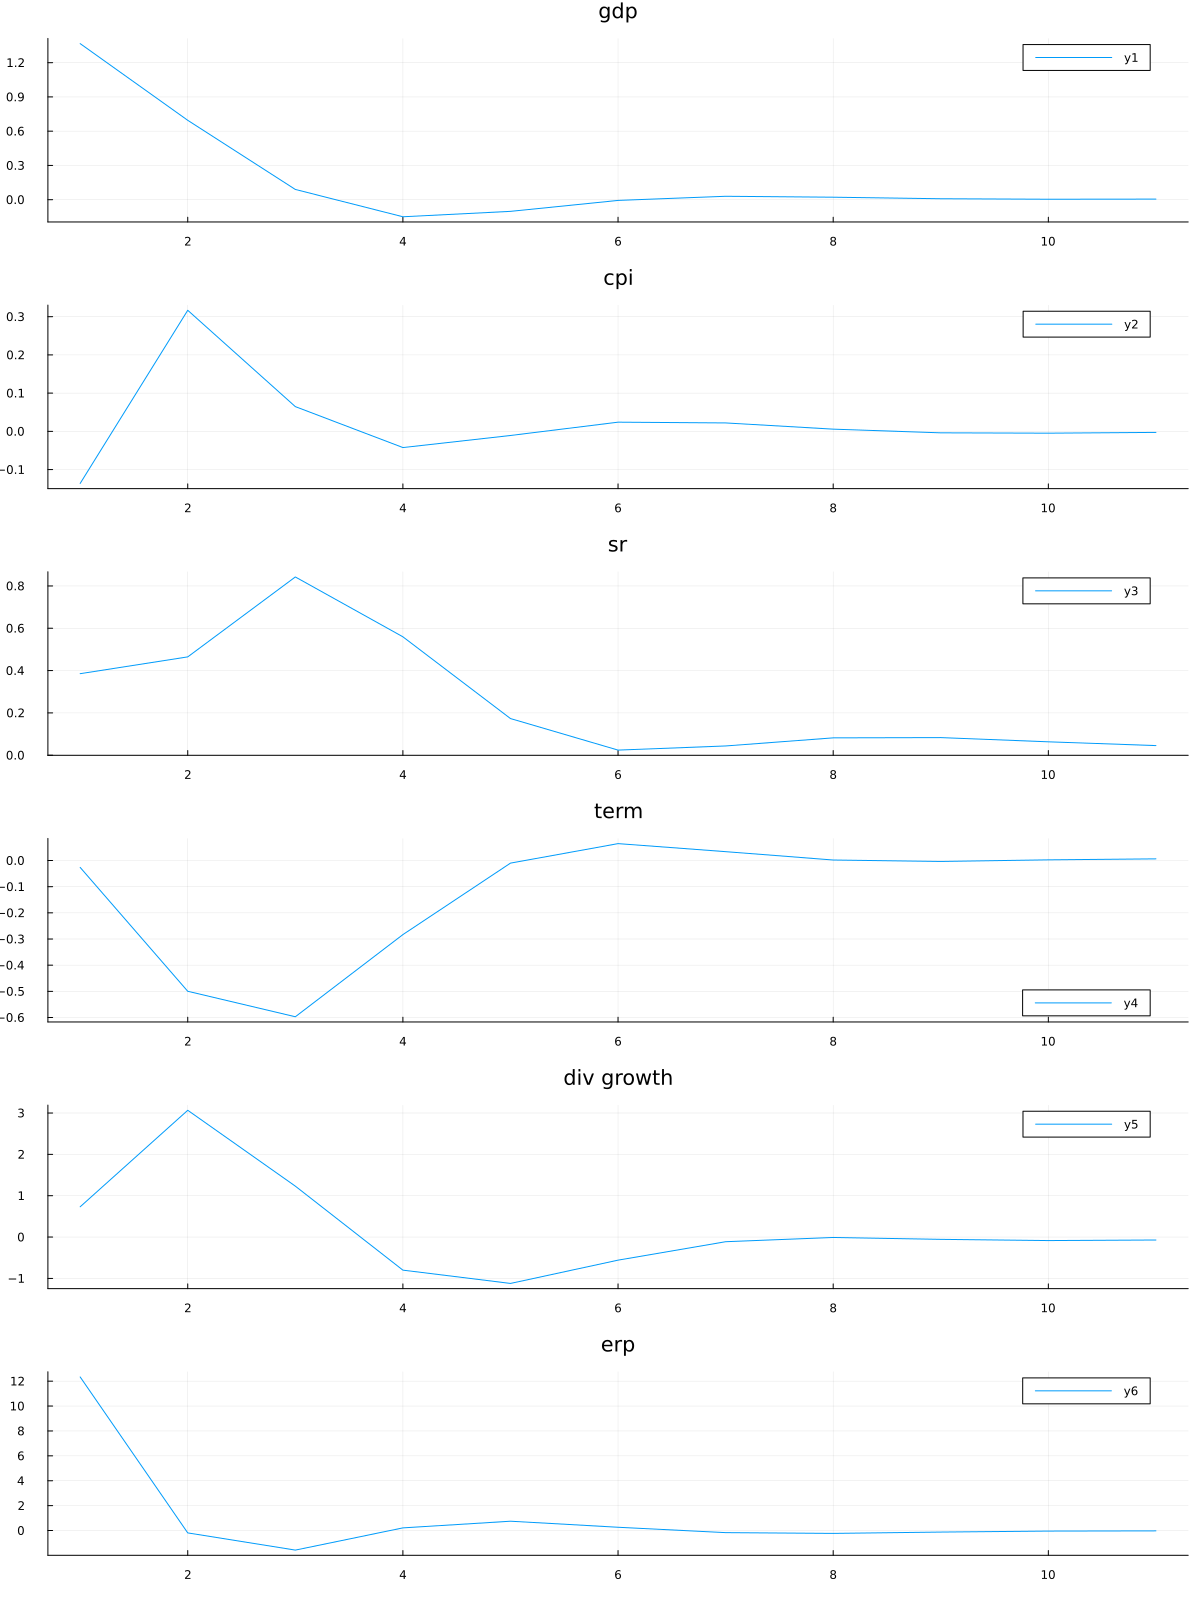

In [208]:
plot(resp; layout = (6,1), size=(1200,1600), title=["gdp" "cpi" "sr" "term" "div growth" "erp"])

In [209]:
display(exp(-3.8 ) *100) 
display(exp(-3.8 + 0.08)*100) 
display((exp(-3.8 ) - exp(-3.8 + 0.08))*100) 
display(0.0224*exp((0.06^2)-1)^.5 *100)
display(exp(-4.8 ) *100) 

2.23707718561656

2.4233967845691122

-0.1863195989525522

1.3610764116758998

0.822974704902003

IRF returns
- estimate dy, and div idnex, based on initial value, mean?
- estimate returns?
- 

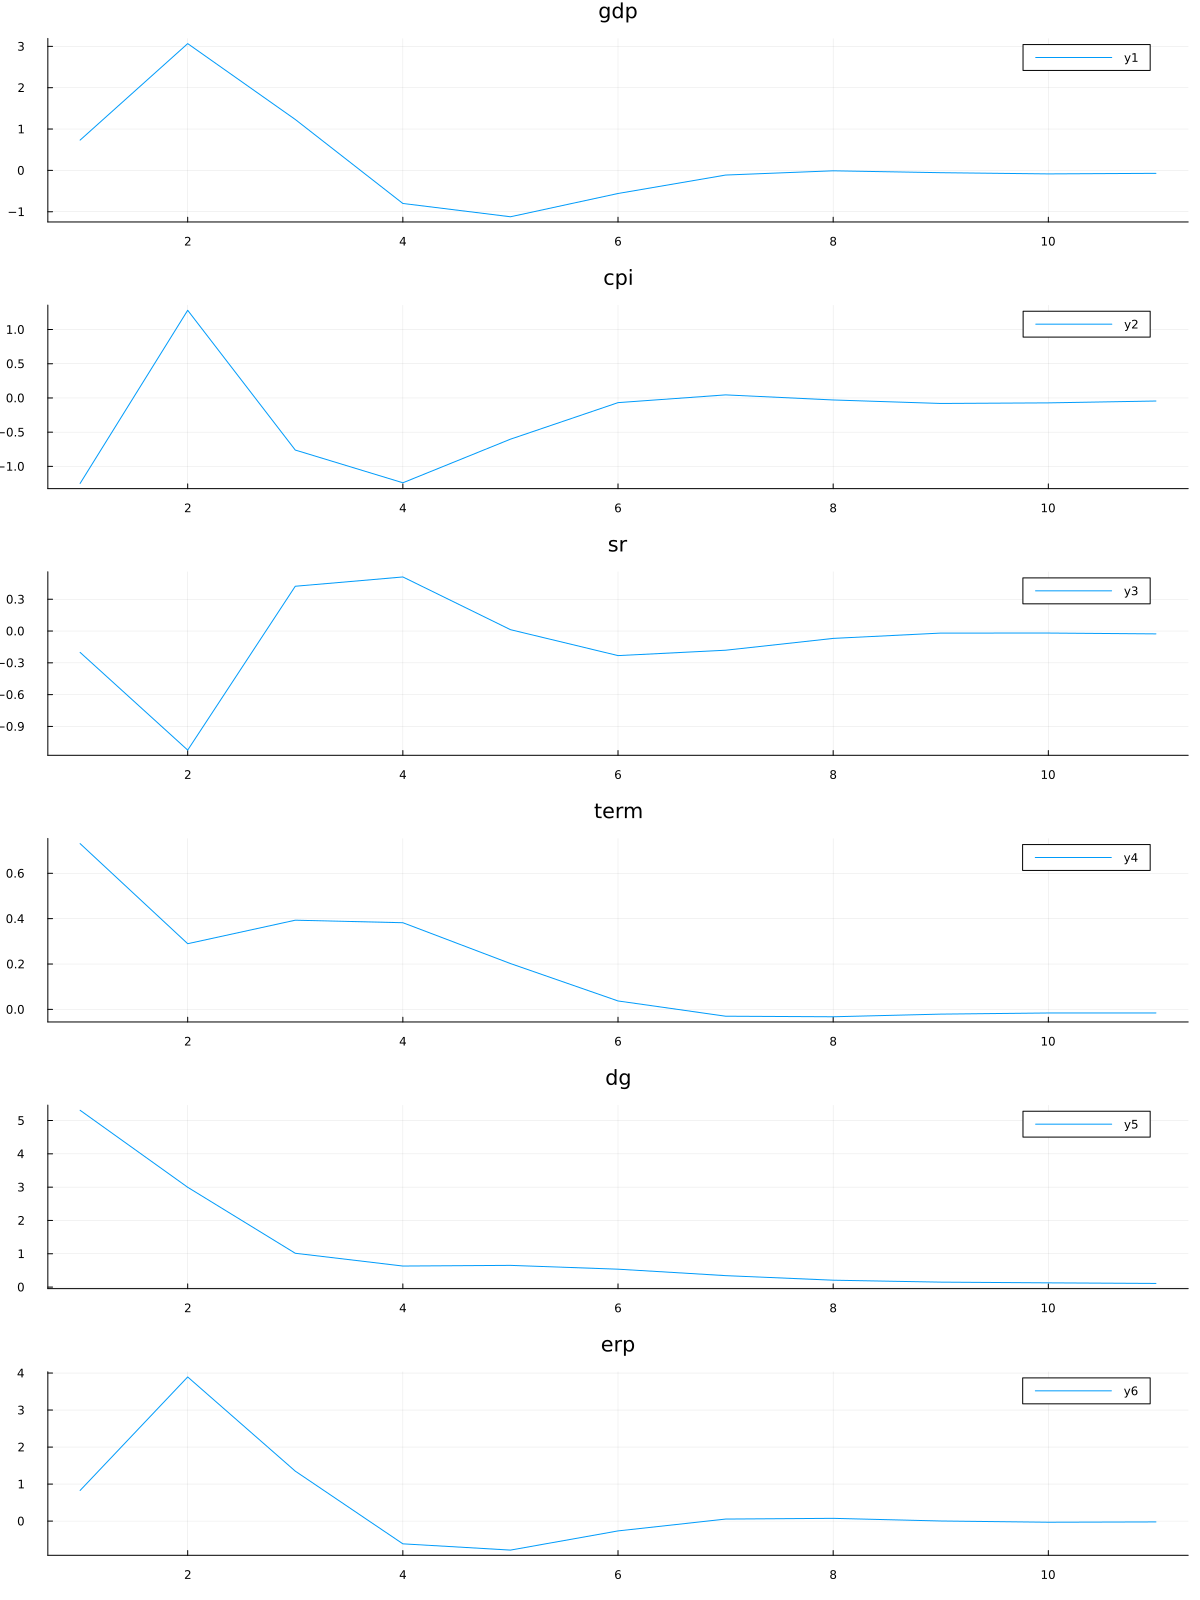

In [210]:
# div growth irf

B = collect(model.C[2:end,:]')

variables = [1,2,3,4,5,6]
result = zeros(11,6)

for (index, v) in enumerate(variables)
    resp = girf(B, model.Σ, 10, v, 1)
    result[:,index] = resp[:,5]
end

plot(result; layout = (6,1), size=(1200,1600), title=["gdp" "cpi" "sr" "term" "dg" "erp"])



In [211]:
fevd = result[1,:] ./ sum(result[1,:]) .* 100
round.(fevd, digits=2)'


1×6 adjoint(::Vector{Float64}) with eltype Float64:
 11.91  -20.32  -3.28  11.89  86.34  13.46

In [212]:
cum_irf = sum(result[1:2,:], dims=1)
fevd2 = cum_irf ./ sum(cum_irf)
round.(fevd2 .* 100)

1×6 Matrix{Float64}:
 23.0  0.0  -8.0  6.0  50.0  29.0

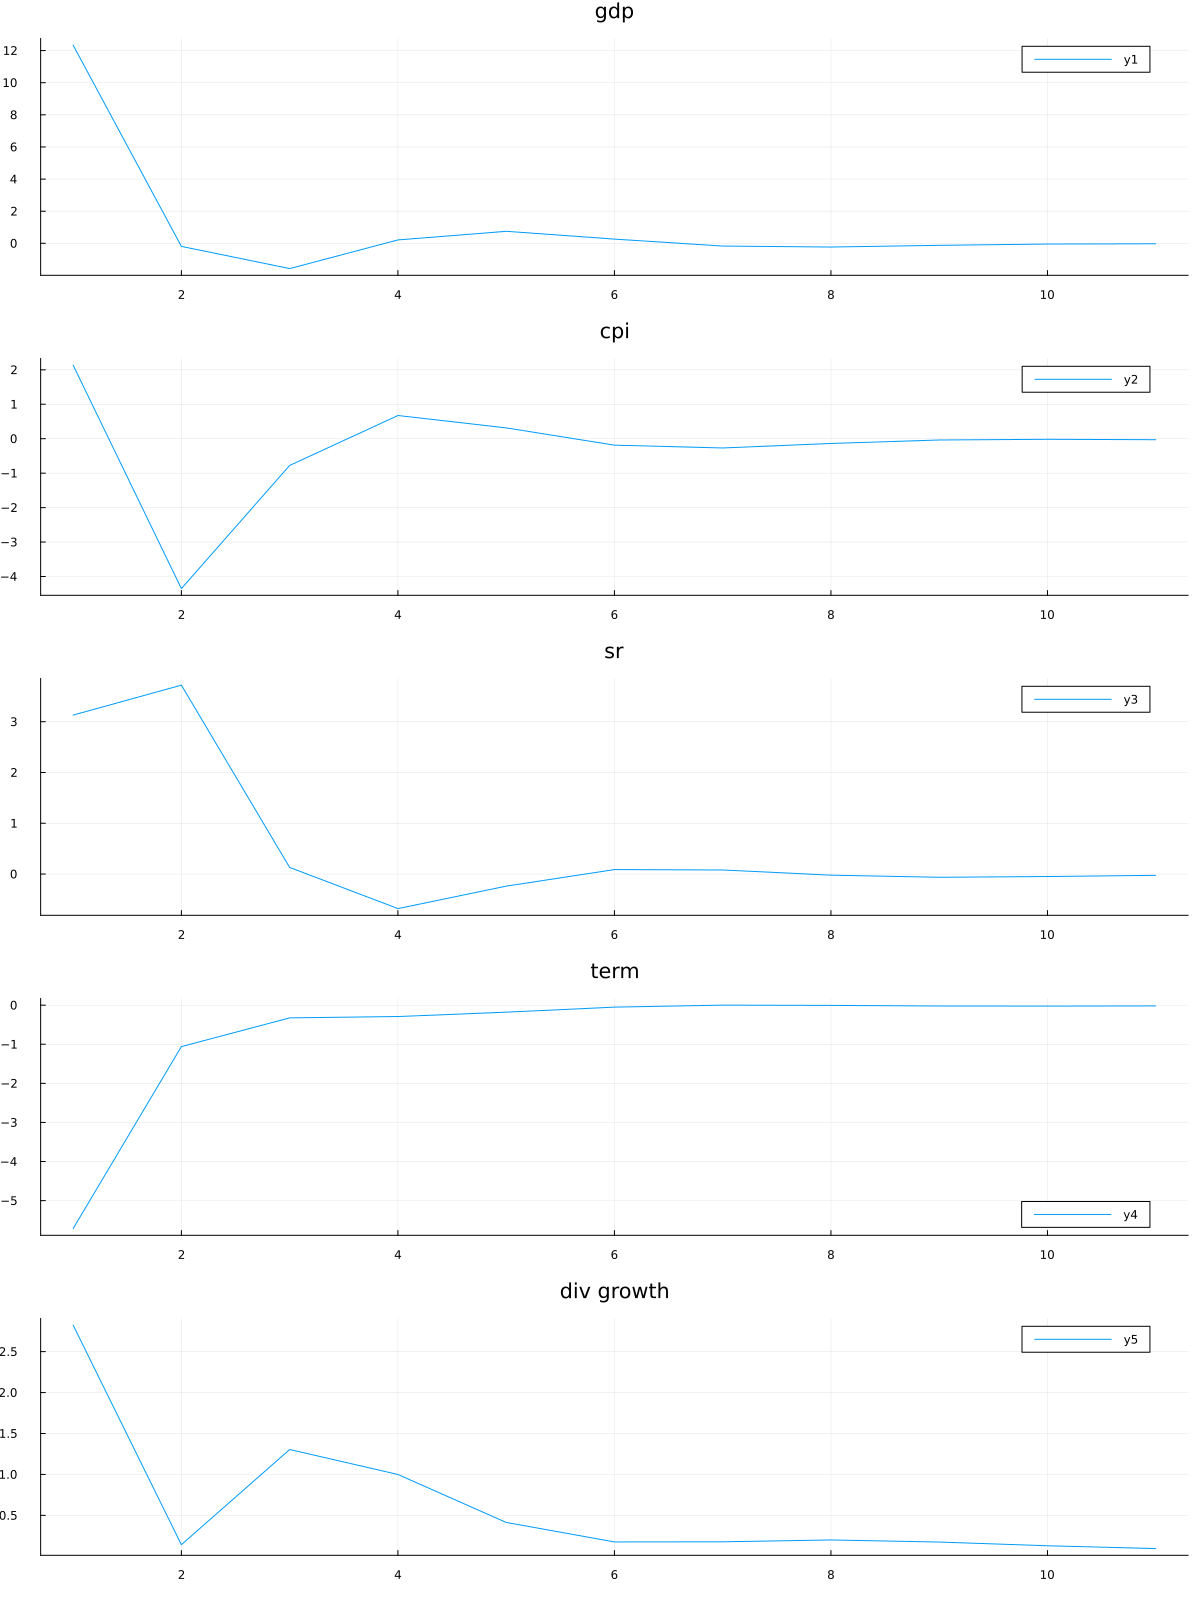

In [213]:
# div yeld irf

B = collect(model.C[2:end,:]')

variables = [1,2,3,4,5]
result = zeros(11,5)

for (index, v) in enumerate(variables)
    resp = girf(B, model.Σ, 10, v, 1)
    result[:,index] = resp[:,6]
end

plot(result; layout = (5,1), size=(1200,1600), title=["gdp" "cpi" "sr" "term" "div growth"])